# Day 5 — End-to-End Machine Learning Pipeline

This notebook focuses on building a complete machine learning pipeline for stroke prediction.

The workflow combines feature engineering, preprocessing, model training, and hyperparameter tuning into a single pipeline.

The final tuned pipeline is evaluated once on a held-out test set and compared with a baseline model.

## Step 1 — Setup and Data Loading

The required libraries are imported for data manipulation, preprocessing, model building, cross-validation, hyperparameter tuning, and evaluation.

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    f1_score,
    recall_score,
    classification_report,
    confusion_matrix
)

import warnings

warnings.filterwarnings(
    "ignore",
    message="Found unknown categories"
)

### Load the Dataset

The stroke dataset is loaded into a pandas DataFrame.

In [2]:
df = pd.read_csv("healthcare-dataset-stroke-data.csv")

df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [3]:
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='str')

## Step 2 — Feature Engineering

The engineered features from Day 4 are added to the dataset.

Two features are used:

- `age_group`: Groups patients into meaningful age categories.
- `health_risk_count`: Counts selected risk factors including hypertension, heart disease, and smoking history.

These features are created before splitting the data because they are deterministic transformations of the existing input features.

Remove the `ID Column`

In [4]:
df = df.drop(columns="id")

### Create `age_group`

The `age_group` feature divides patients into four age categories.

In [5]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 18, 40, 60, 100],
    labels=["Young", "Adult", "Middle_aged", "Senior"]
)

### Create `health_risk_count`

The `health_risk_count` feature represents the number of selected stroke-related risk factors.

The selected factors are:

- Hypertension
- Heart disease
- Smoking history

A higher value indicates a greater number of these selected risk factors.

In [6]:
df["health_risk_count"] = (
    df["hypertension"]
    + df["heart_disease"]
    + df["smoking_status"].isin(
        ["smokes", "formerly smoked"]
    ).astype(int)
)

## Step 3 — Separate Features and Target

The target variable `stroke` is separated from the input features.

In [8]:
X = df.drop(columns="stroke")
y = df["stroke"]

## Step 4 — Train/Test Split

The dataset is divided into training and test sets.

The training set is used for preprocessing, cross-validation, and hyperparameter tuning.

The test set is kept completely separate and is used only once for the final evaluation of the selected pipeline.

Stratification is used to maintain a similar proportion of stroke and non-stroke cases in both sets.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

## Step 5 — Define Numerical and Categorical Features

The features are divided into numerical and categorical groups so that appropriate preprocessing can be applied to each type.

In [9]:
numerical_features = [
    "age",
    "hypertension",
    "heart_disease",
    "avg_glucose_level",
    "bmi",
    "health_risk_count"
]

categorical_features = [
    "gender",
    "ever_married",
    "work_type",
    "Residence_type",
    "smoking_status",
    "age_group"
]

## Step 6 — Build the Preprocessing Pipeline

A `ColumnTransformer` is used to apply different preprocessing steps to numerical and categorical features.

For numerical features:
- Missing values are replaced using the median.
- Features are standardized using `StandardScaler`.

For categorical features:
- Missing values are replaced using the most frequent category.
- Categorical values are converted into numerical form using `OneHotEncoder`.
- `handle_unknown="ignore"` prevents errors when unseen categories appear during cross-validation or testing.

The preprocessing steps are included in the pipeline so that they are fitted only on the training data within each cross-validation fold, helping prevent data leakage.

In [11]:

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numerical_features
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        )
    ]
)

## Step 7 — Build the Full Machine Learning Pipeline

The preprocessing pipeline is combined with a Random Forest classifier into a single machine learning pipeline.

This ensures that preprocessing and model training are performed together during cross-validation.

The Random Forest uses `class_weight="balanced_subsample"` to account for the class imbalance in the stroke dataset.

In [12]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        RandomForestClassifier(
            class_weight="balanced_subsample",
            random_state=42
        )
    )
])

## Step 8 — Define the Hyperparameter Grid

A hyperparameter grid is defined for the Random Forest classifier.

The grid tests different values for the number of trees, maximum tree depth, minimum samples required to split a node, and minimum samples required at a leaf.

These parameters will be evaluated using `GridSearchCV`.

In [13]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

## Step 9 — Define 5-Fold Stratified Cross-Validation

Stratified 5-fold cross-validation is used to evaluate different hyperparameter configurations while maintaining a similar proportion of stroke and non-stroke cases in each fold.

The F1 score is used as the optimization metric because the dataset is highly imbalanced and performance on the minority stroke class is important.

In [14]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

## Step 10 — Tune the Full Pipeline with GridSearchCV

`GridSearchCV` evaluates all combinations of the selected hyperparameters using 5-fold cross-validation.

The search is performed only on the training set.

The held-out test set remains completely separate and is not used during hyperparameter tuning.

In [15]:
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    return_train_score=True
)

In [18]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 10, ...], 'model__min_samples_leaf': [1, 2], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_

## Step 11 — Best Hyperparameters

The best hyperparameter configuration selected by `GridSearchCV` is displayed.

In [19]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 100}


In [20]:
print("Best Cross-Validated F1 Score:")
print(grid_search.best_score_)

Best Cross-Validated F1 Score:
0.18151061173533084


## Step 12 — Baseline Model

A `DummyClassifier` is used as a simple baseline for comparison.

The baseline predicts the majority class for all samples. Since the stroke dataset is highly imbalanced, this provides a useful reference for evaluating whether the tuned pipeline improves the F1 score.

In [31]:
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(
    strategy="most_frequent"
)

baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)

## Step 13 — Baseline Evaluation

The baseline model is evaluated on the held-out test set using the F1 score.

The F1 score is used because the dataset is highly imbalanced and accuracy alone may be misleading.

In [32]:
baseline_f1 = f1_score(
    y_test,
    baseline_pred,
    zero_division=0
)

baseline_recall = recall_score(
    y_test,
    baseline_pred,
    zero_division=0
)

print("Baseline Test F1:", baseline_f1)
print("Baseline Stroke Recall:", baseline_recall)

Baseline Test F1: 0.0
Baseline Stroke Recall: 0.0


## Step 14 — Final Evaluation on the Held-Out Test Set

The best pipeline selected by `GridSearchCV` is evaluated once on the held-out test set.

The test set was not used during hyperparameter tuning, so it provides an unbiased evaluation of the final selected pipeline.

In [23]:
best_pipeline = grid_search.best_estimator_

y_pred = best_pipeline.predict(X_test)

## Step 15 — Final Test Metrics

The F1 score and recall for the stroke class are calculated on the held-out test set.

F1 provides a balance between precision and recall, while recall measures the proportion of actual stroke cases correctly identified by the model.

In [ ]:

test_f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

test_recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

print("Tuned Pipeline Test F1:", test_f1)
print("Tuned Pipeline Stroke Recall:", test_recall)

Tuned Pipeline Test F1: 0.24
Tuned Pipeline Stroke Recall: 0.3


## Step 16 — Compare the Tuned Pipeline with the Baseline

The tuned pipeline is compared with the baseline using F1 score on the same held-out test set.

The improvement in F1 score shows whether the tuned pipeline provides better performance than the majority-class baseline.

In [33]:
improvement = test_f1 - baseline_f1

print("Baseline Test F1:", baseline_f1)
print("Tuned Pipeline Test F1:", test_f1)
print("F1 Improvement:", improvement)

Baseline Test F1: 0.0
Tuned Pipeline Test F1: 0.24
F1 Improvement: 0.24


## Step 17 — F1 Score Comparison

The F1 scores of the baseline and tuned pipeline are visualized to clearly compare their performance on the held-out test set.

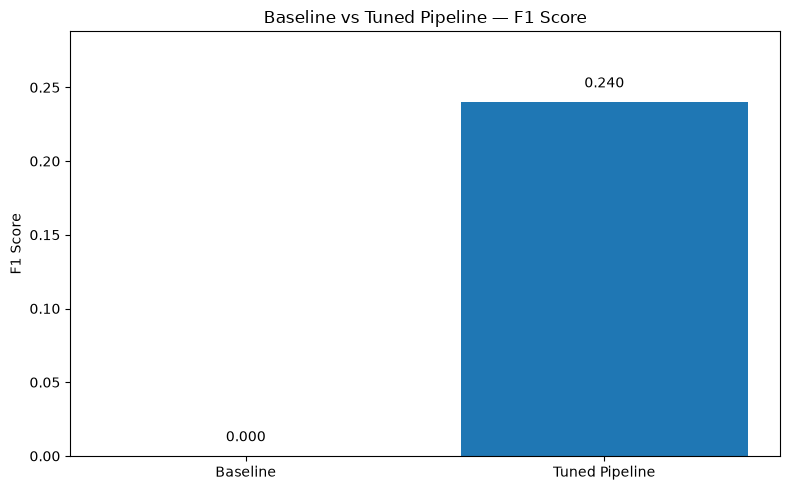

In [ ]:

models = ["Baseline", "Tuned Pipeline"]
f1_scores = [baseline_f1, test_f1]

plt.figure(figsize=(8, 5))

plt.bar(models, f1_scores)

plt.ylabel("F1 Score")
plt.title("Baseline vs Tuned Pipeline — F1 Score")
plt.ylim(0, max(f1_scores) * 1.2)

for i, score in enumerate(f1_scores):
    plt.text(
        i,
        score + 0.01,
        f"{score:.3f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

## Step 18 — Classification Report

The classification report provides precision, recall, and F1 score for both the non-stroke and stroke classes.

Particular attention is given to the stroke class because correctly identifying stroke cases is important for this classification problem.

In [ ]:

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Stroke", "Stroke"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

   No Stroke       0.96      0.94      0.95       972
      Stroke       0.20      0.30      0.24        50

    accuracy                           0.91      1022
   macro avg       0.58      0.62      0.60      1022
weighted avg       0.93      0.91      0.92      1022



## Step 19 — Confusion Matrix

The confusion matrix shows the number of correctly and incorrectly classified cases for the non-stroke and stroke classes.

It helps identify false negatives, which represent actual stroke cases that were incorrectly predicted as non-stroke.

In [36]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[912  60]
 [ 35  15]]


## Step 20 — Final Results

The final results summarize the performance of the tuned pipeline and the baseline on the held-out test set.

The tuned pipeline achieved a higher F1 score and was able to identify a proportion of the actual stroke cases, while the majority-class baseline failed to identify any stroke cases.

In [28]:
print("Final Results")
print("------------------------------")
print("Best Parameters:", grid_search.best_params_)
print("Best CV F1:", grid_search.best_score_)
print("Baseline Test F1:", baseline_f1)
print("Tuned Pipeline Test F1:", test_f1)
print("F1 Improvement:", improvement)

Final Results
------------------------------
Best Parameters: {'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best CV F1: 0.18151061173533084
Baseline Test F1: 0.0
Tuned Pipeline Test F1: 0.24
F1 Improvement: 0.24
